# C1 Practical 21: from the bathtub to the fingerprint

*Lectures 20 and 21. Michaelmas 2026.*


> Open this notebook in Google Colab with the button on the course page, then choose *File > Save a copy in Drive*
> so that your changes are kept. Questions marked **[paper]** are answered on paper. Cells marked *run* need
> only be run; some have settings you can change, which appear as sliders and menus in Colab. A changed setting
> takes effect only when the cell is run again.


**Constants used throughout.** Ice density $\rho_i = 917$ kg m$^{-3}$, fresh water $\rho_w = 1000$ kg m$^{-3}$,
ocean area $A = 3.6\times10^{14}$ m$^2$ (71 per cent of the Earth's surface; radius 6371 km), $g = 9.8$ m s$^{-2}$.

> **Solutions version.** Cells beginning *Answer* are the worked solutions and demonstrator notes.

In [ ]:
#@title Run this cell first. It fetches the data files and a small helper module.
import os, sys, pathlib, urllib.request
BASE = "https://raw.githubusercontent.com/da380/c1-practicals/main/"
here = pathlib.Path("../data") if pathlib.Path("../data/c1prac.py").exists() else pathlib.Path("data")
here.mkdir(exist_ok=True)
if not pathlib.Path("../data/c1prac.py").exists():          # in Colab: always fetch the current helper module
    urllib.request.urlretrieve(BASE + "data/c1prac.py", here / "c1prac.py")
    for m in [k for k in sys.modules if k == "c1prac"]:
        del sys.modules[m]
sys.path.insert(0, str(here))
try:
    import pyslfp
except ImportError:                       # in Colab: about a minute
    import subprocess; subprocess.run([sys.executable, "-m", "pip", "install", "-q", "pyslfp"], check=True); import pyslfp
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
from pyslfp import subplots
from c1prac import get, global_map, point_value, ocean_mean, earth_state, fingerprint
print("Ready.")

## 1. The bathtub, flotation, and what counts  [paper]

**(a)** Suppose global temperatures are stabilised at $2\,^\circ$C above pre-industrial. Estimate the sea level
change due to thermal expansion, taking the thermal expansion coefficient of water to be
$\alpha = 2.14\times10^{-4}$ K$^{-1}$, defined by $\Delta V / V = \alpha\,\Delta T$, and the mean ocean depth to be
4 km. Comment on the accuracy of the result and on the main uncertainties.

**(b)** The Greenland ice sheet has a volume of $2.85\times10^{15}$ m$^3$. Using the bathtub model, estimate the
global mean sea level rise if it melted entirely. The world's glaciers and ice caps are equivalent to 0.32 m of
sea level; what is their mass? Show that 360 Gt of ice corresponds to one millimetre of sea level, and convert the
present-day loss rates of Greenland (about 260 Gt yr$^{-1}$) and Antarctica (about 135 Gt yr$^{-1}$) into rates of
sea level rise.

**(c)** Let $SL$ denote relative sea level (positive over the ocean), $S$ the water thickness and $I$ the ice thickness
at a point where an ice shelf floats. By balancing the weight of the ice against the water it displaces, show that
$$ S = SL - \frac{\rho_i}{\rho_w}\, I . $$
Hence find the ice thickness at which ice grounded on a bed below sea level begins to float.

**(d)** The West Antarctic ice sheet contains $2.2\times10^{15}$ m$^3$ of ice. What does the bathtub model give for
its sea-level equivalent? The accepted value is about 4 m. Use your result from (c) to explain the difference,
and say which kinds of ice do and do not contribute to sea level when they melt.

**Answer.** **(a)** A column of depth $D = 4000$ m expands by $\alpha\,\Delta T\, D = 2.14\times10^{-4}\times 2\times 4000
\approx 1.7$ m. This is an upper limit for the equilibrium response, and a poor guide to the response over a
century, for two reasons. The expansion coefficient of sea water depends strongly on temperature (and pressure):
it is near zero at $4\,^\circ$C and rises to over $3\times10^{-4}$ K$^{-1}$ in warm surface water, so a single
value is not appropriate for the whole column. And the ocean does not warm uniformly: over decades to centuries only
the upper few hundred metres warm appreciably, so the realised expansion is a fraction of the equilibrium value. A
700 m layer warming by 2 K gives about 0.3 m. The deep ocean takes millennia to equilibrate.

**(b)** Mass $M = \rho_i V = 917\times 2.85\times10^{15} = 2.6\times10^{18}$ kg. Spread over the ocean as water:
$\Delta SL = M/(\rho_w A) = 2.6\times10^{18}/(1000\times3.6\times10^{14}) \approx 7.2$ m.
Glaciers: $M = \rho_w A \times 0.32 = 1.2\times10^{17}$ kg, about 120 000 Gt.
One millimetre needs $\rho_w A\times10^{-3} = 3.6\times10^{14}$ kg $= 360$ Gt. So 260 Gt yr$^{-1}$ is 0.72 mm yr$^{-1}$
and 135 Gt yr$^{-1}$ is 0.38 mm yr$^{-1}$; together about 1.1 mm yr$^{-1}$, a third of the present global mean rate.

**(c)** Floating ice displaces its own weight of water. A column of ice of thickness $I$ has weight $\rho_i g I$ per unit
area; the water column beneath it, of thickness $S$, plus the ice, together reach up to the sea surface, so $S + (\rho_i/\rho_w) I = SL$,
giving $S = SL - (\rho_i/\rho_w) I$. Grounded ice on a bed at depth $d$ below sea level ($SL = d$) floats when $S > 0$, that is when
$I < (\rho_w/\rho_i)\, d \approx 1.09\, d$. Ice thicker than this is grounded.

**(d)** Bathtub: $917\times2.2\times10^{15}/(1000\times3.6\times10^{14}) = 5.6$ m. The accepted 4 m is smaller because
much of West Antarctica rests on a bed one to two kilometres below sea level. When such ice melts, sea water floods the
cavity it leaves, and only the part of the ice column above flotation, $I - (\rho_w/\rho_i)d$, adds water to the ocean;
the remainder merely replaces itself. Floating ice shelves contribute nothing (apart from a small effect of the density
difference between fresh melt water and sea water); grounded ice above sea level contributes fully; marine-based grounded
ice contributes only its excess above flotation. This is why the sea-level equivalents quoted in Lecture 20 refer to
"grounded ice above flotation".

## 2. The grounding line on a real bed  [paper]

The figure shows the bed elevation and ice thickness from the ETOPO 2022 grids along a line running from the
open Amundsen Sea shelf, across the grounding line of Thwaites Glacier, and into the interior of West Antarctica.
Run the cell to draw it together with the flotation thickness from question 1(c).

In [ ]:
#@title Run: bed, ice and flotation thickness along the Thwaites line
d = np.genfromtxt(get("thwaites_transect.csv"), delimiter=",", names=True)
x, bed, H = d["distance_km"], d["bed_m"], d["ice_thickness_m"]
Hf = np.where(bed < 0, 1000.0 / 917.0 * (-bed), 0.0)          # flotation thickness for the local bed depth
floating = (H > 0) & (H < Hf)
fig, ax = plt.subplots(2, 1, figsize=(10.4, 8.45), sharex=True)
ax[0].fill_between(x, bed, -2500, color="0.75", label="bed")
base = np.where(floating, -0.917 * H, bed); surf = np.where(floating, 0.083 * H, bed + H)
ax[0].fill_between(x, base, surf, where=H > 0, color="lightblue", label="ice")
ax[0].axhline(0, ls="--", color="C0", lw=0.8, label="sea level")
ax[0].set_ylabel("elevation / m"); ax[0].legend(frameon=False, loc="upper right"); ax[0].set_ylim(-2300, 2300)
ax[1].plot(x, H, label="ice thickness $I$ (ETOPO)")
ax[1].plot(x, Hf, label="flotation thickness $(\\rho_w/\\rho_i)\\,d$")
ax[1].set_xlabel("distance from the open shelf / km"); ax[1].set_ylabel("thickness / m"); ax[1].legend(frameon=False)
plt.show()
gl = x[np.argmax((H > 0) & ~floating)]
print(f"The ice first grounds about {gl:.0f} km along the line; the bed there is at {np.interp(gl, x, bed):.0f} m.")

**(a)** Read off the bed depth at the grounding line and hence the ice thickness there. Now suppose the grounding line
retreats by 250 km along the line. What is the flotation thickness at the new position?

**(b)** The discharge of ice across the grounding line rises steeply with the thickness there: as $H^5$ if the ice
deforms internally, as $u_b H$ if it slides. Is a small retreat of this grounding line opposed or amplified? Explain
in terms of the shape of the bed.

**(c)** Lecture 21 showed that the relative sea level next to a melting ice sheet *falls*, by several times the global
mean rise; on the Amundsen Sea coast the fall is about six times the mean (question 3). Which way does this push the
grounding line, and does it oppose or reinforce the feedback in (b)? For each metre of global mean rise from West
Antarctica, by how much does the flotation thickness at the present grounding line change? Compare this with the ice
thickness there, and with the change in flotation thickness produced by a small retreat along the bed, which
deepens inland at about 4 m per kilometre.

**Answer.** **(a)** From the plot the ice grounds at about 150 km, where the bed is at roughly $-600$ m, so the flotation
thickness there is about $1.09\times600 \approx 650$ m. 250 km further inland the bed lies near $-1800$ m and the
flotation thickness is about 2000 m: three times thicker.

**(b)** Amplified. The bed is retrograde: it deepens towards the interior. A retreat puts the grounding line in deeper
water, the ice there must be thicker to remain grounded, and a thicker grounding line discharges far more ice
($3^5 \approx 240$ times more by internal deformation, three times more by sliding at fixed speed, and in practice the
sliding speeds up as well). The ice sheet behind thins, the grounding line retreats further, and there is no equilibrium
until the bed rises again. This is the marine ice sheet instability.

**(c)** Near the ice the relative sea level falls, so the water at the grounding line becomes shallower, the flotation
thickness decreases and the discharge is reduced: a negative feedback, opposing the instability in (b). One metre of
global mean rise from West Antarctica lowers local sea level by about 6 m and the flotation thickness by
$1.09\times6 \approx 7$ m, about one per cent of the 650 m of ice at the grounding line. With the bed deepening at
4 m per kilometre, the flotation thickness grows by about 4.4 m for every kilometre of retreat, so the sea level fall
from a metre of global rise (a third of the ice sheet) is worth less than two kilometres of grounding-line position. On an elastic Earth the feedback is
real but weak. Whether the solid Earth can do more than this is a question for Lecture 22 and Practical 22.

## 3. Fingerprints  [run]

The following cells show sea level fingerprints computed by solving the sea level equation for a spherically
symmetric elastic Earth (PREM), with rotational feedback included. Each fingerprint is divided by its bathtub
value, so that the average over the ocean is exactly one. Change the settings and rerun.

**Rotation, briefly.** Lecture 21 described the gravitational and deformational parts of the response to a load
and only mentioned that the load also perturbs the Earth's rotation. The fingerprints here include that third
part. Moving mass from an ice sheet into the ocean changes the Earth's inertia tensor. Two things follow. The spin
slows slightly, because mass has moved away from the axis towards the equator, like a skater extending her arms.
And the rotation axis tilts slightly. The centrifugal potential changes with the axis, so the sea surface, an
equipotential, moves; and the solid Earth deforms under the changed centrifugal force just as it does under any
other load. This *rotational feedback* is small beside the other two parts but has a distinctive pattern.

**Which way does the pole move?** A spinning body settles into rotation about the axis of greatest moment of
inertia, the axis about which its mass is spread out the most; for the Earth that is the polar axis, because of
the equatorial bulge. Now remove some mass from Greenland. The mass distribution is no longer symmetric about the
old axis: there is a deficit on Greenland's side. The axis of greatest inertia is the one that keeps the most mass
far from itself, and it therefore tilts so as to bring the *deficit* closer to the pole, that is, it tilts towards
Greenland. The rotation axis follows it, and the North Pole moves along Greenland's meridian towards Greenland
(panel a). The rule is: the pole nearer the melting ice moves towards it. For West Antarctica the South Pole moves
towards West Antarctica, so the North Pole moves along the opposite meridian, away from it. The motion is tiny, of
order a metre for the ice loss of a decade, but the centrifugal potential is so large that even this matters.

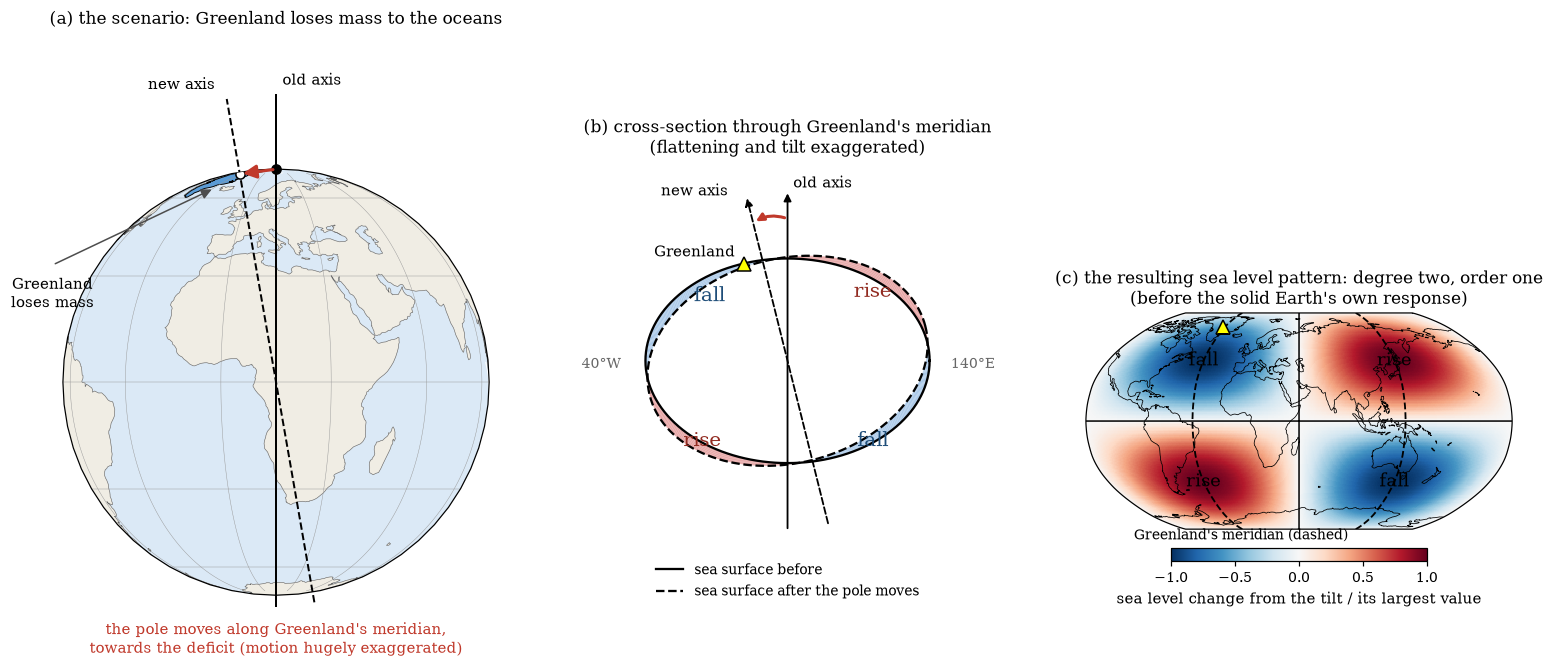<p style="font-size:90%;color:#444"><em>How Greenland's melt moves the pole and what that does to sea level. (a) The scenario. (b) The cross-section through Greenland's meridian: the sea surface, flattened about the rotation axis, tilts with the axis. (c) The difference between the tilted and the original surface, over the whole sphere.</em></p>

**Why four quadrants?** The rotational part of the fingerprint is nothing more than the difference between an
ellipsoid and the same ellipsoid tilted slightly. The equilibrium sea surface is flattened about the rotation
axis. When the pole moves by a small angle $\delta$ towards Greenland, the whole surface tilts with it. Follow
Greenland's meridian in panel (b). North of the equator on Greenland's side, the flattened polar region has come
closer, so the surface *falls*; on the opposite side of the same cross-section, at $140^\circ$E, the bulge has
moved in and the surface *rises*. South of the equator the two are exchanged: a rise on Greenland's side, a fall at
$140^\circ$E. Ninety degrees round from this plane, over the Pacific and over the Indian Ocean, the tilt moves the
surface along itself and nothing changes, and nothing changes on the equator either. Two positive and two negative
lobes, largest at $45^\circ$ latitude and separated by the equator and by one meridian great circle (panel c):
that is the spherical harmonic $\sin\theta\cos\theta\cos(\phi-\phi_0)$ of degree two and order one, and it
is what panel (c) of cell B maps. The solid Earth then deforms under this changed potential, which reduces the
amplitude by about a third but leaves the pattern alone.

**Cell A.** Choose an ice sheet. The cell builds the present-day Earth model, solves the sea level equation for
that ice sheet (the first run also downloads the ice model and the Love numbers, which takes a moment) and maps the
result. The setting `lmax` is the highest spherical harmonic degree kept: higher values resolve finer detail near
the coasts at the cost of time, mostly in the plotting. 128 is enough for this practical, but raise it if you are
curious; cell B uses whatever you chose here. Note the near-field minimum, the far-field maximum, and where the zero
contour runs. Values at some named sites are printed.

In [ ]:
#@title Cell A: the fingerprint of an ice sheet
source = "Greenland"  #@param ["Greenland", "West Antarctica", "East Antarctica"]
include_rotation = True  #@param {type:"boolean"}
lmax = 128  #@param [64, 128, 256, 512] {type:"raw"}
st = earth_state(int(lmax))
load = {"Greenland": st.greenland_load, "West Antarctica": st.west_antarctic_load, "East Antarctica": st.east_antarctic_load}[source]()
r = fingerprint(st, load, rotation=include_rotation)
lon, lat, ocean, sl = r["lon"], r["lat"], r["ocean"], r["sl"]
sites = {"Brest": (48.4, -4.5), "Halifax": (44.7, -63.6), "Honolulu": (21.3, -157.9), "Sydney": (-33.9, 151.2),
         "Simonstown": (-34.2, 18.4), "Faraday": (-65.2, -64.3), "Reykjavik": (64.2, -21.9), "Barbados": (13.1, -59.5)}
fig, ax = global_map(sl, lon, lat, vmin=-8, vmax=1.6, center=0, ocean=ocean, contours=(0.0, 1.0), sites=sites,
                     label="relative sea level change / bathtub value", title=f"{source} fingerprint" + ("" if include_rotation else " (no rotation)"))
plt.show()
oc = np.where(ocean > 0, sl, np.nan)
print(f"ocean average = {ocean_mean(sl, lon, lat, ocean):.3f};  near-field minimum = {np.nanmin(oc):.2f};  far-field maximum = {np.nanmax(oc):.2f}")
for name, (la, lo) in sites.items():
    print(f"  {name:<11s} {point_value(sl, lon, lat, la, lo):6.2f}")

**Cell B.** Split the fingerprint into its two parts, the vertical motion of the solid surface and the change in the
geoid, and map the contribution of rotation alone (the difference between the fingerprint with and without rotational
feedback).

In [ ]:
#@title Cell B: uplift, gravity, and the rotational part
source = "West Antarctica"  #@param ["Greenland", "West Antarctica", "East Antarctica"]
st = earth_state(int(globals().get("lmax", 128)))   # the degree chosen in cell A
load = {"Greenland": st.greenland_load, "West Antarctica": st.west_antarctic_load, "East Antarctica": st.east_antarctic_load}[source]()
r = fingerprint(st, load, rotation=True)
r0 = fingerprint(st, load, rotation=False)
lon, lat, ocean = r["lon"], r["lat"], r["ocean"]
fig, axes = subplots(2, 2, ccrs.Robinson(), figsize=(16.9, 10.4))
for k, (ax, field, title) in enumerate(zip(axes.flat, [-r["uplift"], r["geoid"], r["sl"] - r0["sl"], r["sl"]],
                                           ["(a) from vertical motion of the solid surface, $-\\Delta u$", "(b) from the change in the geoid, $-\\Delta\\varphi/g$",
                                            "(c) rotational feedback alone", "(d) the fingerprint"])):
    lim = 0.25 if k == 2 else 5.0
    global_map(field, lon, lat, ax=ax, vmin=-lim, vmax=lim if k == 2 else 1.6, center=0, ocean=ocean, contours=(0.0,), title=title, label="/ bathtub value")
plt.show()
rot = np.where(ocean > 0, r["sl"] - r0["sl"], np.nan)
print(f"rotational part: largest magnitude over the ocean {np.nanmax(np.abs(rot)):.2f} of the bathtub value")

**Questions [paper].**

**(a)** Describe the main features of the West Antarctic fingerprint and explain, in terms of the response of the solid
Earth and of the gravitational field, why they arise. Quantify the near-field fall, the far-field excess, the distance to
the zero contour, and the relative size of the uplift and gravitational parts.

**(b)** How large is the rotational part? Check that it has the pattern described above, and say which way the
pole moves when West Antarctica loses mass.

**(c)** The ocean average of every map in cells A and B is exactly one. Which physical principle guarantees this?

**Answer.** **(a)** Near West Antarctica relative sea level *falls*, by up to about 8.2
times the bathtub value; the zero contour lies roughly 2000 km from the ice; far from it sea level rises by up to
1.32 times the bathtub value, with the largest values
in the opposite hemisphere. Two effects cause the near-field fall: removing the load lets the solid surface rebound
(the sea floor rises, so relative sea level falls), and removing the mass of ice reduces its gravitational attraction, so
the geoid falls and the water that was piled up around the ice sheet slumps away. At the point of largest fall about
60 per cent is uplift and 40 per cent gravity (cell B).

**(b)** About 15 per cent of the bathtub value for West Antarctica and
17 per cent for Greenland: small but not negligible. The pattern is the
degree-two, order-one harmonic of the figure, with nodes on the equator and on the great circle through the poles at right
angles to the meridian of West Antarctica (about $100^\circ$W): sea level falls in the northern quadrant on the Indian
Ocean side and in the southern quadrant on the Pacific side, and rises in the other two. Removing mass from West Antarctica
moves the axis of greatest inertia towards the deficit, so the south pole moves towards West Antarctica and the north pole
towards the opposite meridian, about $80^\circ$E, which is the meridian on which the northern hemisphere falls.

**(c)** Conservation of mass: the water added to the oceans equals the ice lost, and this fixes the uniform constant in
the solution of the sea level equation. It is also why the bathtub value is the barystatic sea level rise, whatever
the pattern.

## 4. The ocean's own contribution  [run]

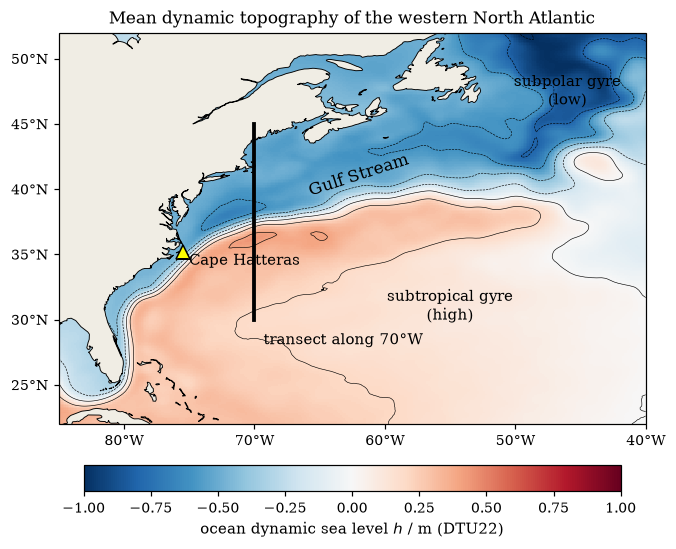<p style="font-size:90%;color:#444"><em>Mean dynamic topography of the western North Atlantic from the DTU22 model (altimetry minus a satellite geoid). The Gulf Stream is the sharp step between the high of the subtropical gyre and the low to its north; the black line is the transect plotted below.</em></p>

The Gulf Stream separates from the American coast at Cape Hatteras and flows east and then north-east across the
Atlantic, along the steep slope in the map. The cell plots the mean ocean dynamic sea level $h$ along the
$70^\circ$W line.

In [ ]:
#@title Run: dynamic topography across the Gulf Stream at 70 W
d = np.genfromtxt(get("gulfstream_mdt_transect.csv"), delimiter=",", names=True)
plt.figure(figsize=(9.1, 4.68)); plt.plot(d["lat"], d["dynamic_topography_m"]); plt.grid(alpha=0.3)
plt.xlabel("latitude / degrees N along 70 W"); plt.ylabel("ocean dynamic sea level h / m"); plt.show()
i = np.argmin(np.gradient(d["dynamic_topography_m"], d["lat"]))
print(f"steepest slope at {d['lat'][i]:.1f} N: {np.gradient(d['dynamic_topography_m'], d['lat'])[i]:.2f} m per degree of latitude")

**(a)** Read off the height and width of the step across the current. Using the geostrophic relation
$u = -\dfrac{g}{f}\dfrac{\partial h}{\partial y}$ with $f = 2\Omega\sin\lambda$, estimate the surface speed and its
direction. The model is a long-term mean that has been smoothed over about 200 km, whereas the core of the real
current is only 50 to 100 km wide and its position wanders from month to month. Given this, are the observed
surface speeds of 1 to 2 m s$^{-1}$ in the core consistent with your estimate?

**(b)** Why does the water not simply flow down the slope of the sea surface?

**Answer.** **(a)** The surface drops by about 1 m between $36.5^\circ$N and $38.5^\circ$N, a distance of about 220 km, so
$\partial h/\partial y \approx -4.5\times10^{-6}$. At $37.5^\circ$N, $f = 2\times7.29\times10^{-5}\times0.61 = 8.9\times10^{-5}$ s$^{-1}$,
and $u = -(9.8/8.9\times10^{-5})\times(-4.5\times10^{-6}) \approx 0.5$ m s$^{-1}$, positive, so eastward: the current
flows with the high surface on its right, as it must in the northern hemisphere. Yes, consistent: the metre of
height difference is real, but the smoothing and the wandering of the current spread it over 200 km or more, so the
model slope is a lower bound. Concentrate the same step over the 50 to 100 km of the real core and the slope, and
hence the speed, are two to four times larger, giving 1 to 2 m s$^{-1}$. The scaling of Lecture 21,
$H \sim \Omega L V/g$, gives the same metre-high step for $L \sim 100$ km and $V \sim 1$ m s$^{-1}$.

**(b)** On a rotating Earth a parcel accelerating down the slope is deflected by the Coriolis force, to the right in the
northern hemisphere, until the pressure-gradient force and the Coriolis force balance and the flow runs along the
contours of $h$. This is the geostrophic balance, and it holds for any flow that is slow compared with the rotation
(small Rossby number) and steady over more than a day or so. The currents therefore circulate around the highs and
lows of the sea surface rather than filling them in.